1. importul librariilor si incarcarea datelor
In aceasta etapa incarcam setul de date brut "Credit Risk Dataset" de pe Kaggle
analizam dimensiunea tabelului
tipurile de date (numerice si text)
identificam primele probleme legate de valorile lipsa

In [9]:

import matplotlib.pyplot as plt  
import numpy as np
import pandas as pd 
import seaborn as sns 

df = pd.read_csv("credit_risk_dataset.csv")
print(f"Dimensiune: {df.shape} (linii, coloane)\n")
print(df.info())
print(df.head())

Dimensiune: (32581, 12) (linii, coloane)

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None

2. curatarea datelor si gestionarea valorilor vipsa (3 Metode)
eliminam randurile duplicate pentru a evita dublarea informatiilor.
filtram datele pentru a asigura logica de business (doar persoane majore >= 18 ani).
Aplicam 3 metode pentru valori lipsa: imputare cu mediana, imputare cu media de grup (folosind `groupby`) si drop 

In [10]:

numar_initial = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Au fost eliminate {numar_initial - len(df)} randuri duplicate.")
df = df[df["person_age"] >= 18].reset_index(drop=True)
#met1-inlocuim valorile lipsa cu mediana
mediana_angajare = df["person_emp_length"].median()
df["person_emp_length"] = df["person_emp_length"].fillna(mediana_angajare)
#met2-calculeaza media dobanzii doar pentru acea clasa si o pune in celulele goale
df["loan_int_rate"] = df.groupby("loan_grade")["loan_int_rate"].transform("mean")
#met3-stergem valorile goale care au mai ramas
df = df.dropna()
print("\nVerificare valori lipsa dupa curatare:")
print(df.isnull().sum())

Au fost eliminate 165 randuri duplicate.

Verificare valori lipsa dupa curatare:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


 3. detectarea si plafonarea valorilor extreme (outliers)
Definim o functie personalizata bazata pe metoda statistica IQR
in loc sa stergem randurile cu venituri sau varste extreme, folosim `np.clip` pentru a le plafona si a pastra volumul de date

In [11]:
def curata_outliers_iqr(data_frame, coloana):
    Q1 = data_frame[coloana].quantile(0.25)
    Q3 = data_frame[coloana].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    data_frame[coloana] = np.clip(data_frame[coloana], lim_inf, lim_sup)
    return lim_inf, lim_sup

lim_inf_age, lim_sup_age = curata_outliers_iqr(df, "person_age")
lim_inf_inc, lim_sup_inc = curata_outliers_iqr(df, "person_income")
lim_inf_emp, lim_sup_emp = curata_outliers_iqr(df, "person_emp_length")

print("Outlierii au fost curățați și plafonați prin metoda IQR!")
print(df[["person_age", "person_income", "person_emp_length"]].describe())

Outlierii au fost curățați și plafonați prin metoda IQR!
         person_age  person_income  person_emp_length
count  32416.000000   32416.000000       32416.000000
mean      27.451922   62437.029831           4.682718
std        5.274139   31807.394422           3.719366
min       20.000000    4000.000000           0.000000
25%       23.000000   38542.000000           2.000000
50%       26.000000   55000.000000           4.000000
75%       30.000000   79218.000000           7.000000
max       40.500000  140232.000000          14.500000


 4. feature eng: encodare si creare de metrici Noi
Transformam datele text in cifre prin One-Hot encoding (`pd.get_dummies`) si label encoding manual pentru clasele de risc ordonate.
cream 3 caracteristici noi relevante pentru analiza riscului financiar: rata de indatorare, proportia vietii muncite si un indicator de risc ridicat combinat.

In [12]:

grade_mapping = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
df["loan_grade_encoded"] = df["loan_grade"].map(grade_mapping)
#transform textul în coloane cu 0 și 1,
#iar apoi sterg prima coloana noua care s-a creat pentru fiecare categorie(poate deduce valoarea lipsa)
df = pd.get_dummies(df, columns=["person_home_ownership", "loan_intent"], drop_first=True, dtype=int)
df["cb_person_default_on_file"] = (
    df["cb_person_default_on_file"].map({"Y": 1, "N": 0}).fillna(0)
)
#features
df["loan_to_income_ratio"] = df["loan_amnt"] / df["person_income"]
df["emp_to_age_ratio"] = df["person_emp_length"] / (df["person_age"] + 1)
df["high_risk_indicator"] = (
    (df["loan_int_rate"] > 12) & (df["loan_grade_encoded"] >= 3)
).astype(int)

if "loan_grade" in df.columns:
    df = df.drop(columns=["loan_grade"])
print(f"Noua marime a tabelului (avem mai multe coloane acum): {df.shape}")

Noua marime a tabelului (avem mai multe coloane acum): (32416, 21)


 5. normalizarea matematica a datelor (min-max scaling)
Aducem toate variabilele numerice la aceeasi scara (in intervalul 0 si 1) utilizand formula  `(X - Min) / (Max - Min)` Salvam rezultatul in `kaggle_credit_risk_cleaned.csv`.

In [13]:
# --- NORMALIZARE FOLOSIND DOAR FORMULA MATEMATICĂ (Fără module externe) ---
cols_to_scale = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_to_income_ratio",
    "emp_to_age_ratio",
]

for col in cols_to_scale:
    col_min = df[col].min()
    col_max = df[col].max()
    # Aplicăm formula: (X - Min) / (Max - Min) pentru a aduce valorile în [0, 1]
    df[col] = (df[col] - col_min) / (col_max - col_min)

# Salvăm datasetul real curățat sub numele corect
df.to_csv("kaggle_credit_risk_cleaned.csv", index=False)

print("Datasetul real de pe Kaggle a fost normalizat matematic și salvat!")
print(df[["person_age", "person_income", "loan_amnt"]].head())

Datasetul real de pe Kaggle a fost normalizat matematic și salvat!
   person_age  person_income  loan_amnt
0    0.097561       0.403723   1.000000
1    0.048780       0.041106   0.014493
2    0.243902       0.041106   0.144928
3    0.146341       0.451436   1.000000
4    0.195122       0.369957   1.000000


6. eda - graficele
Generam o matrice 2x2 de sub-grafice 
1. Distributia veniturilor (Histplot)
2. Impactul dobanzii asupra neplatii (Boxplot)
3. Relatia dintre varsta, venit si default (Scatterplot)
4. Legaturile dintre variabile (Correlation Heatmap)

C:\Users\User1\AppData\Local\Temp\ipykernel_15136\2238124419.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


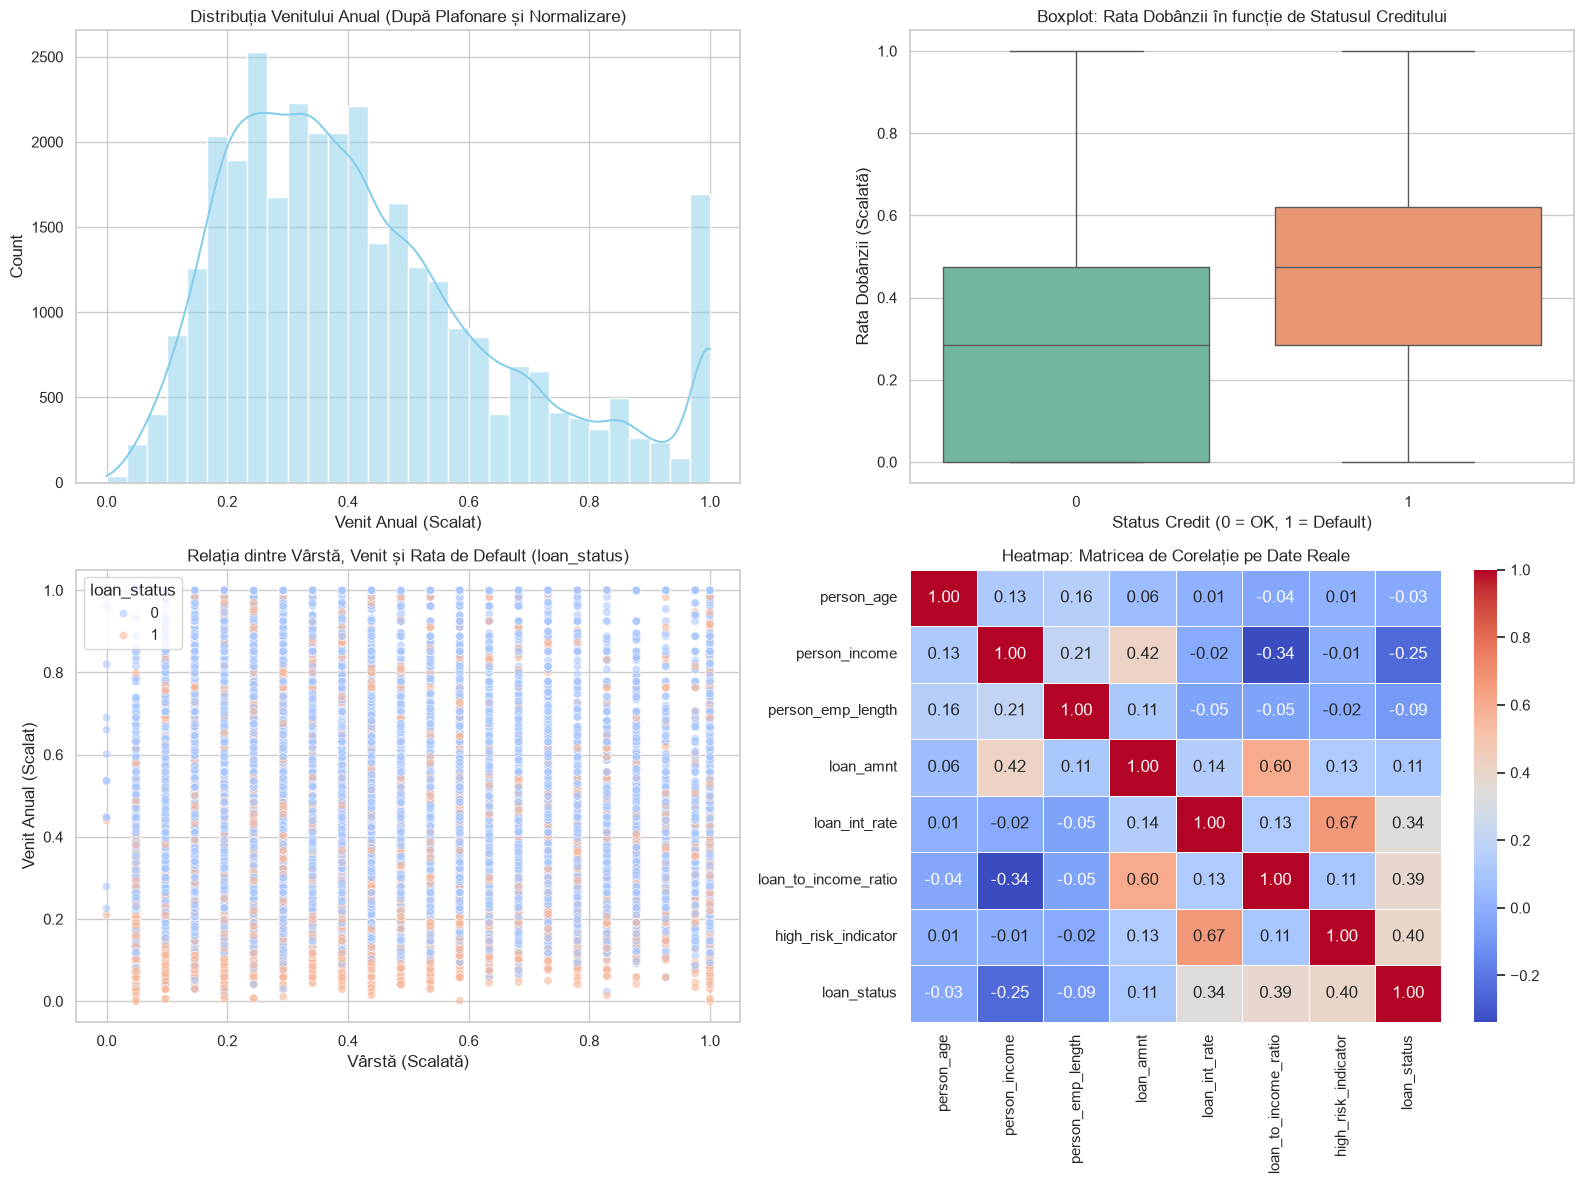

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Creăm o matrice de grafice: 2 rânduri și 2 coloane
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribuția Venitului Anual
sns.histplot(
    df["person_income"], kde=True, ax=axes[0, 0], color="skyblue", bins=30
)
axes[0, 0].set_title("Distribuția Venitului Anual (După Plafonare și Normalizare)")
axes[0, 0].set_xlabel("Venit Anual (Scalat)")

sns.boxplot(
    x="loan_status", y="loan_int_rate", data=df, ax=axes[0, 1], palette="Set2"
)
axes[0, 1].set_title("Boxplot: Rata Dobânzii în funcție de Statusul Creditului")
axes[0, 1].set_xlabel("Status Credit (0 = OK, 1 = Default)")
axes[0, 1].set_ylabel("Rata Dobânzii (Scalată)")

#Relația dintre Vârstă, Venit și Rata de Default
sns.scatterplot(
    x="person_age",
    y="person_income",
    hue="loan_status",
    data=df,
    ax=axes[1, 0],
    palette="coolwarm",
    alpha=0.6,
)
axes[1, 0].set_title("Relația dintre Vârstă, Venit și Rata de Default (loan_status)")
axes[1, 0].set_xlabel("Vârstă (Scalată)")
axes[1, 0].set_ylabel("Venit Anual (Scalat)")

#Matricea de Corelație
# Selectăm doar o parte din coloane sa fie ok de citit
cols_pentru_corr = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_to_income_ratio",
    "high_risk_indicator",
    "loan_status",
]
corr_matrix = df[cols_pentru_corr].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Heatmap: Matricea de Corelație pe Date Reale")

# Ajustăm spațiul dintre grafice ca să nu se suprapună textele
plt.tight_layout()
plt.show()